<a href="https://colab.research.google.com/github/johnlwilson223-web/Python-projects/blob/main/Exercise_15_8_Iris_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [3]:
k_range = range(1, 31)
mean_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    mean_scores.append(scores.mean())

    print(f"k = {k}, accuracy = {scores.mean():.4f}")

k = 1, accuracy = 0.9600
k = 2, accuracy = 0.9533
k = 3, accuracy = 0.9667
k = 4, accuracy = 0.9667
k = 5, accuracy = 0.9667
k = 6, accuracy = 0.9667
k = 7, accuracy = 0.9667
k = 8, accuracy = 0.9667
k = 9, accuracy = 0.9733
k = 10, accuracy = 0.9667
k = 11, accuracy = 0.9667
k = 12, accuracy = 0.9733
k = 13, accuracy = 0.9800
k = 14, accuracy = 0.9733
k = 15, accuracy = 0.9733
k = 16, accuracy = 0.9733
k = 17, accuracy = 0.9733
k = 18, accuracy = 0.9800
k = 19, accuracy = 0.9733
k = 20, accuracy = 0.9800
k = 21, accuracy = 0.9667
k = 22, accuracy = 0.9667
k = 23, accuracy = 0.9733
k = 24, accuracy = 0.9600
k = 25, accuracy = 0.9667
k = 26, accuracy = 0.9600
k = 27, accuracy = 0.9667
k = 28, accuracy = 0.9533
k = 29, accuracy = 0.9533
k = 30, accuracy = 0.9533


In [4]:
best_score = max(mean_scores)
best_k = list(k_range)[mean_scores.index(best_score)]

print("Best k:", best_k)
print("Best cross-validated accuracy:", best_score)

Best k: 13
Best cross-validated accuracy: 0.9800000000000001


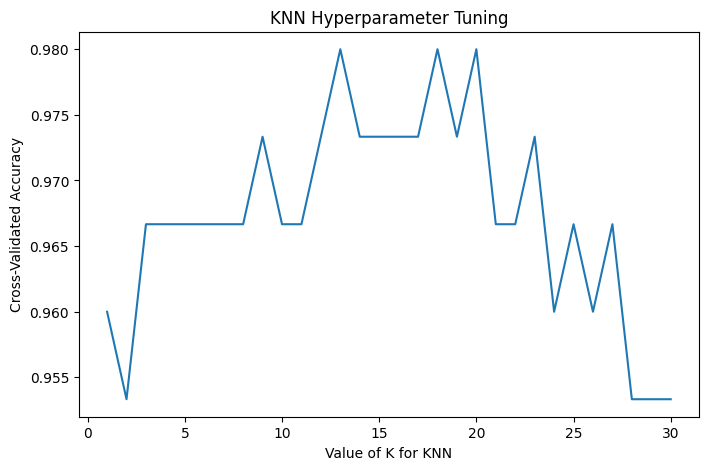

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(k_range, mean_scores)

plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Hyperparameter Tuning")

plt.show()

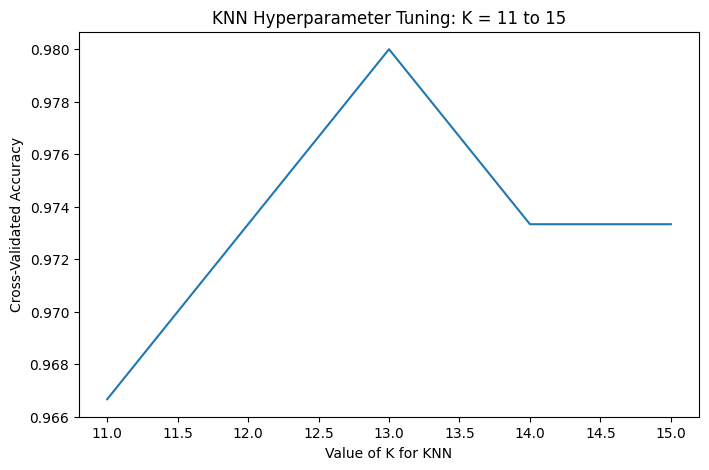

In [6]:
zoom_k = range(11, 16)
zoom_scores = mean_scores[10:15]

plt.figure(figsize=(8, 5))

plt.plot(zoom_k, zoom_scores)

plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Hyperparameter Tuning: K = 11 to 15")

plt.show()

In [7]:
param_grid = {
    "n_neighbors": range(1, 31)
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=10
)

grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'n_neighbors': 13}
Best score: 0.9800000000000001


## Conclusion

K-Nearest Neighbors models were evaluated using k values from 1 to 30
with 10-fold cross-validation.

The optimal value was k = 13, which achieved a cross-validated accuracy
of approximately 0.98.

GridSearchCV also confirmed that the optimal hyperparameter was
n_neighbors = 13 with an accuracy of approximately 0.98.